# Block reduction approaches

Trying to transform the block

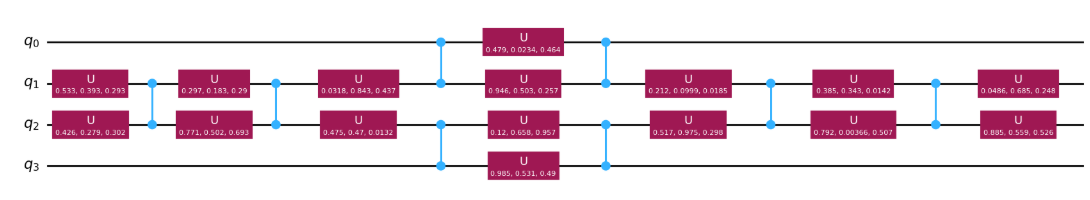

to the block 

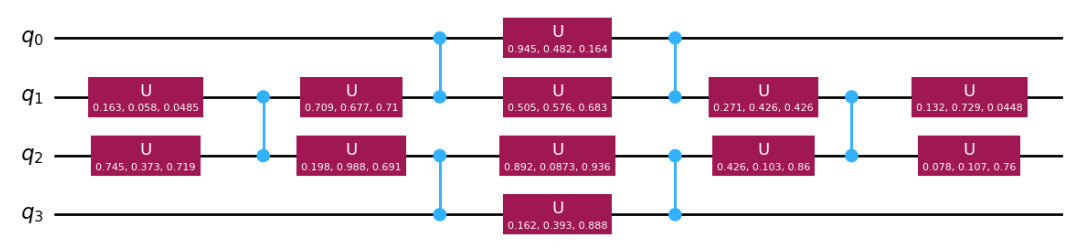

In [1]:
import qiskit
from qiskit import QuantumRegister as Q_R
from qiskit import ClassicalRegister as C_R

from qiskit.quantum_info import Operator
from qiskit.visualization import array_to_latex
from IPython.display import display

import numpy as np
import random
import copy

# SciPy minimizer routine
from scipy.optimize import minimize

PI = np.pi

In [12]:
def block_4_circ(par):
    q_2 = qiskit.QuantumCircuit(4)
    q_2.u(par[0], par[1], par[2], 1)
    q_2.u(par[3], par[4], par[5], 2)
    q_2.cz(1,2)
    q_2.u(par[6], par[7], par[8], 1)
    q_2.u(par[9], par[10], par[11], 2)
    q_2.cz(1,2)
    q_2.u(par[12], par[13], par[14], 1)
    q_2.u(par[15], par[16], par[17], 2)
    
    q_2.cz(0,1)
    q_2.u(par[18], par[19], par[20], 0)
    q_2.u(par[21], par[22], par[23], 1)
    q_2.cz(0,1)
    
    q_2.cz(2,3)
    q_2.u(par[24], par[25], par[26], 2)
    q_2.u(par[27], par[28], par[29], 3)
    q_2.cz(2,3)
    
    q_2.u(par[30], par[31], par[32], 1)
    q_2.u(par[33], par[34], par[35], 2)
    q_2.cz(1,2)
    q_2.u(par[36], par[37], par[38], 1)
    q_2.u(par[39], par[40], par[41], 2)
    q_2.cz(1,2)
    q_2.u(par[42], par[43], par[44], 1)
    q_2.u(par[45], par[46], par[47], 2)
    
    return q_2

def block_4(par):
    q_2 = qiskit.QuantumCircuit(4)
    q_2.u(par[0], par[1], par[2], 1)
    q_2.u(par[3], par[4], par[5], 2)
    q_2.cz(1,2)
    q_2.u(par[6], par[7], par[8], 1)
    q_2.u(par[9], par[10], par[11], 2)
    q_2.cz(1,2)
    q_2.u(par[12], par[13], par[14], 1)
    q_2.u(par[15], par[16], par[17], 2)
    
    q_2.cz(0,1)
    q_2.u(par[18], par[19], par[20], 0)
    q_2.u(par[21], par[22], par[23], 1)
    q_2.cz(0,1)
    
    q_2.cz(2,3)
    q_2.u(par[24], par[25], par[26], 2)
    q_2.u(par[27], par[28], par[29], 3)
    q_2.cz(2,3)
    
    q_2.u(par[30], par[31], par[32], 1)
    q_2.u(par[33], par[34], par[35], 2)
    q_2.cz(1,2)
    q_2.u(par[36], par[37], par[38], 1)
    q_2.u(par[39], par[40], par[41], 2)
    q_2.cz(1,2)
    q_2.u(par[42], par[43], par[44], 1)
    q_2.u(par[45], par[46], par[47], 2)
    
    op = Operator(q_2)
    return op

def reduced_block_4_circ(par):
    q_2 = qiskit.QuantumCircuit(4)
    q_2.u(par[0], par[1], par[2], 1)
    q_2.u(par[3], par[4], par[5], 2)
    q_2.cz(1,2)
    q_2.u(par[6], par[7], par[8], 1)
    q_2.u(par[9], par[10], par[11], 2)
    
    q_2.cz(0,1)
    q_2.u(par[12], par[13], par[14], 0)
    q_2.u(par[15], par[16], par[17], 1)
    q_2.cz(0,1)
    
    q_2.cz(2,3)
    q_2.u(par[18], par[19], par[20], 2)
    q_2.u(par[21], par[22], par[23], 3)
    q_2.cz(2,3)
    
    q_2.u(par[24], par[25], par[25], 1)
    q_2.u(par[25], par[28], par[29], 2)
    q_2.cz(1,2)
    q_2.u(par[30], par[31], par[32], 1)
    q_2.u(par[33], par[34], par[35], 2)
    
    return q_2

def reduced_block_4(par):
    q_2 = qiskit.QuantumCircuit(4)
    q_2.u(par[0], par[1], par[2], 1)
    q_2.u(par[3], par[4], par[5], 2)
    q_2.cz(1,2)
    q_2.u(par[6], par[7], par[8], 1)
    q_2.u(par[9], par[10], par[11], 2)
    
    q_2.cz(0,1)
    q_2.u(par[12], par[13], par[14], 0)
    q_2.u(par[15], par[16], par[17], 1)
    q_2.cz(0,1)
    
    q_2.cz(2,3)
    q_2.u(par[18], par[19], par[20], 2)
    q_2.u(par[21], par[22], par[23], 3)
    q_2.cz(2,3)
    
    q_2.u(par[24], par[25], par[25], 1)
    q_2.u(par[25], par[28], par[29], 2)
    q_2.cz(1,2)
    q_2.u(par[30], par[31], par[32], 1)
    q_2.u(par[33], par[34], par[35], 2)
    
    op = Operator(q_2)
    return op

cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}

def double_q_diff(mat_1, mat_2):
    mm = mat_1 - mat_2
    return np.linalg.norm(mm)

def estim_func(params, params_init):
    init_circ = block_4(params_init)
    test_circ = reduced_block_4(params)
    est = double_q_diff(init_circ, test_circ)
    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(est)
    return est
    
def find_alt_params(param_init):
    find = 0
    for i in range(10):
        param_0 = np.random.rand(36)
        cost_history_dict = {
            "prev_vector": None,
            "iters": 0,
            "cost_history": [],
        }
        res = minimize(
                    estim_func,
                    param_0,
                    args = (param_init),
                    method = 'cobyla', 
                    options = {"maxiter":  5000} 
                )
        if res.fun < 0.1:
            break
    
    return res

In [3]:
#random_array = np.random.rand(48)
#qc = block_4(random_array)
#qc.draw('mpl')

In [4]:
#random_array = np.random.rand(36)
#qc = reduced_block_4(random_array)
#qc.draw('mpl')

In [6]:
params_init = np.random.rand(48)
params_init

array([0.17871431, 0.64709149, 0.62056657, 0.82252272, 0.60970789,
       0.72652688, 0.13071127, 0.87522239, 0.41851607, 0.85835882,
       0.54667536, 0.7012657 , 0.03815558, 0.50411177, 0.13609154,
       0.25578566, 0.89858252, 0.8766303 , 0.64884235, 0.16993785,
       0.12317032, 0.39255142, 0.64461142, 0.06027103, 0.88800053,
       0.47752542, 0.79835757, 0.01473807, 0.78717144, 0.70099307,
       0.30601416, 0.27880899, 0.18568341, 0.5837671 , 0.17282228,
       0.69253004, 0.74977332, 0.11033463, 0.46553   , 0.80368795,
       0.75912057, 0.11231205, 0.69660316, 0.76386529, 0.31327693,
       0.14031065, 0.5205832 , 0.70224285])

In [7]:
import time
start_time = time.time()

new_params = []
block_devs = []
for i in range(1):
    res_min = find_alt_params(params_init)
    new_params.append(res_min.x)
    block_devs.append(res_min.fun)
    
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time} seconds")

Elapsed time: 825.7585935592651 seconds


In [8]:
block_devs

[1.6144590973420236]

In [9]:
new_params

[array([-0.05102944,  0.56330691,  0.07447445,  2.11256906,  1.40089424,
         0.71672068, -0.13353242,  1.18017109, -0.47469648,  1.46914825,
         0.42792109,  2.19723837,  0.60650768,  0.16778488,  0.1257467 ,
         0.23242448,  1.60229011,  0.45930351,  0.83010033,  0.48762532,
         1.33776309, -0.00602587,  1.01413445,  0.47525346, -0.06094142,
        -0.70417977, -0.04436871,  0.65418404,  0.36668671,  0.70348468,
         0.73766159,  0.98128508, -0.03351634,  2.18140301,  1.07967561,
        -0.18344023])]

In [23]:
qc_init = block_4_circ(params_init)
qc_init.measure_all()
qc_red = reduced_block_4_circ(new_params[0])
qc_red.measure_all()

In [27]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile
simulator = AerSimulator()
qc_merged_t = transpile(qc_init, simulator)
result = simulator.run(qc_merged_t,shots = 1000).result()
counts_init = result.get_counts(qc_merged_t)

In [28]:
simulator = AerSimulator()
qc_merged_t = transpile(qc_red, simulator)
result = simulator.run(qc_merged_t,shots = 1000).result()
counts_red = result.get_counts(qc_merged_t)

In [31]:
print(sorted(counts_init.items(), key=lambda item: item[1], reverse=True) )
print(sorted(counts_red.items(), key=lambda item: item[1], reverse=True) )



[('0100', 564), ('0000', 179), ('0010', 116), ('0101', 85), ('0110', 26), ('0011', 21), ('0001', 7), ('0111', 2)]
[('0100', 631), ('0000', 129), ('0110', 119), ('0101', 58), ('0010', 28), ('0001', 21), ('0111', 10), ('0011', 4)]


In [33]:
matr_init = block_4(params_init)
matr_red = reduced_block_4(new_params[0])
matr_init - matr_red

Operator([[ 1.09638056e-02-1.05333446e-01j,
           -4.49467532e-03+4.55993870e-02j,
           -9.51366196e-02+1.09248705e-01j,
            1.78936436e-02+7.02019508e-02j,
            1.81218596e-01+1.17955082e-01j,
           -5.60520526e-02-6.24304388e-02j,
           -2.54861883e-01-6.26811390e-02j,
           -1.40553196e-01-9.55709855e-02j,
           -6.08689490e-03+9.20286818e-04j,
            1.99167291e-03-4.50993355e-04j,
            2.24907165e-03-2.14126806e-03j,
            5.96565494e-04-8.38530755e-04j,
           -2.20570799e-03-1.04814788e-04j,
            5.63193578e-04+1.74715999e-04j,
           -1.58615482e-03-1.45117635e-03j,
           -6.15232101e-04-3.95435294e-04j],
          [-1.60935804e-02+7.37851462e-03j,
           -3.43790072e-02+1.06712448e-01j,
            3.97564541e-02-5.55475533e-02j,
           -2.12117368e-01+1.75558392e-03j,
            4.66959299e-02+3.55871302e-02j,
            1.84936844e-01+1.81408736e-02j,
            9.78402609e-02+8.70